# Створення нейронної мережі

У цьому завданні ми створимо повнозв'язну нейронну мережу, використовуючи при цьому низькорівневі механізми tensorflow.

Архітектура нейромережі представлена на наступному малюнку. Як бачиш, у ній є один вхідний шар, два приховані, а також вихідний шар. В якості активаційної функції у прихованих шарах буде використовуватись сигмоїда. На вихідному шарі ми використовуємо softmax.

Частина коду зі створення мережі вже написана, тобі потрібно заповнити пропуски у вказаних місцях.

## Архітектура нейронної мережі

<img src="http://cs231n.github.io/assets/nn1/neural_net2.jpeg" alt="nn" style="width: 400px;"/>


## Про датасет MNIST

Дану нейромережу ми будемо вивчати на датасеті MNIST. Цей датасет являє собою велику кількість зображень рукописних цифр розміром $28 \times 28$ пікселів. Кожен піксель приймає значення від 0 до 255.

Як і раніше, датасет буде розділений на навчальну та тестову вибірки. При цьому ми виконаємо нормалізацію всіх зображень, щоб значення пікселів знаходилось у проміжку від 0 до 1, розділивши яскравість кожного пікселя на 255.

Окрім того, архітектура нейронної мережі очікує на вхід вектор. У нашому ж випадку кожен об'єкт вибірки являє собою матрицю. Що ж робити? У цьому завданні ми "розтягнемо" матрицю $28 \times 28$, отримавши при цьому вектор, що складається з 784 елементів.

![MNIST Dataset](https://www.researchgate.net/profile/Steven-Young-5/publication/306056875/figure/fig1/AS:393921575309346@1470929630835/Example-images-from-the-MNIST-dataset.png)

Більше інформації про датасет можна знайти [тут](http://yann.lecun.com/exdb/mnist/).

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import keras as K
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import torch
from torch import nn

In [2]:
num_classes = 10 # загальна кількість класів, у нашому випадку це цифри від 0 до 9
num_features = 784 # кількість атрибутів вхідного вектора 28 * 28 = 784

learning_rate = 0.001 # швидкість навчання нейронної мережі
training_steps = 3000 # максимальне число епох
batch_size = 256 # перераховувати ваги мережі ми будемо не на всій вибірці, а на її випадковій підмножині з batch_size елементів
display_step = 100 # кожні 100 ітерацій ми будемо показувати поточне значення функції втрат і точності

n_hidden_1 = 128 # кількість нейронів 1-го шару
n_hidden_2 = 256 # кількість нейронів 2-го шару

In [3]:
# from tensorflow.keras.datasets import mnist
from keras.datasets import mnist

# Завантажуємо датасет
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Перетворюємо цілочисельні пікселі на тип float32
x_train, x_test = np.array(x_train, np.float32), np.array(x_test, np.float32)

# Перетворюємо матриці розміром 28x28 пікселів у вектор з 784 елементів
x_train, x_test = x_train.reshape([-1, num_features]), x_test.reshape([-1, num_features])

# Нормалізуємо значення пікселів
x_train, x_test = x_train / 255., x_test / 255.

# Перемішаємо тренувальні дані
train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_data = train_data.repeat().shuffle(5000).batch(batch_size).prefetch(1)

test_data = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_data = test_data.repeat().shuffle(5000).prefetch(1)

In [109]:
# Створимо нейронну мережу

class DenseLayer(tf.Module):
    def __init__(self, in_features, out_features, name=None):
        super().__init__(name=name)
        self.w = tf.Variable(
            tf.random.normal([in_features, out_features]), name="w"
        )
        self.b = tf.Variable(tf.zeros([out_features]), name="b")

    def __call__(self, x, activation=0):
        y = tf.matmul(x, self.w) + self.b
        if activation != 0:
            return tf.nn.softmax(y)
        else:
            return tf.nn.sigmoid(y)

class NN(tf.Module):
  def __init__(self, name=None):
    super().__init__(name=name)
    # Перший шар, який складається з 128 нейронів
    self.l1 = DenseLayer(num_features, n_hidden_1)
    # Другий шар, який складається з 256 нейронів
    self.l2 = DenseLayer(n_hidden_1, n_hidden_2)
    # Вихідний шар
    self.l3 = DenseLayer(n_hidden_2, num_classes)


  def __call__(self, x):
    # Передача даних через перші два шари та вихідний шар з функцією активації softmax
    x = self.l1(x)
    x = self.l2(x)

    return self.l3(x, activation=1)

In [110]:
# В якості функції помилки в даному випадку зручно взяти крос-ентропію
def cross_entropy(y_pred, y_true):
    # Закодувати label в one hot vector
    y_true = tf.one_hot(y_true, depth=num_classes)

    # Значення передбачення, щоб уникнути помилки log(0).
    y_pred = tf.clip_by_value(y_pred, 1e-9, 1.)

    # Обчислення крос-ентропії
    return tf.reduce_mean(-tf.reduce_sum(y_true * tf.math.log(y_pred)))

# Як метрику якості використовуємо точність
def accuracy(y_pred, y_true):
    predicted = tf.argmax(y_pred, axis=1)
    y_true = tf.cast(y_true, tf.int64)

    correct_predictions = tf.equal(predicted, y_true)

    return tf.reduce_mean(tf.cast(correct_predictions, tf.float32))

In [111]:
# Створимо екземпляр нейронної мережі
neural_net = NN(name="mnist")
optimizer = tf.optimizers.SGD(learning_rate)

# Функція навчання нейромережі
def train(neural_net: NN, input_x, output_y):
    with tf.GradientTape() as g:
        pred = neural_net(input_x)
        loss = cross_entropy(pred, output_y)

    grads = g.gradient(loss, neural_net.trainable_variables)
    optimizer.apply_gradients(zip(grads, neural_net.trainable_variables))

    return loss

In [112]:
# Тренування мережі

loss_history = []  # кожні display_step кроків зберігай в цьому списку поточну помилку нейромережі
accuracy_history = [] # кожні display_step кроків зберігай в цьому списку поточну точність нейромережі

# У цьому циклі ми будемо проводити навчання нейронної мережі
# із тренувального датасета train_data вилучи випадкову підмножину, на якій
# відбудеться тренування. Використовуй метод take, доступний для тренувального датасета.
for step, (batch_x, batch_y) in enumerate(train_data.take(training_steps), 1):
    step_loss = train(neural_net, batch_x, batch_y)

    if step % display_step == 0:
        pred = neural_net(batch_x)

        loss_history.append(step_loss)
        accuracy_history.append(accuracy(pred, batch_y))

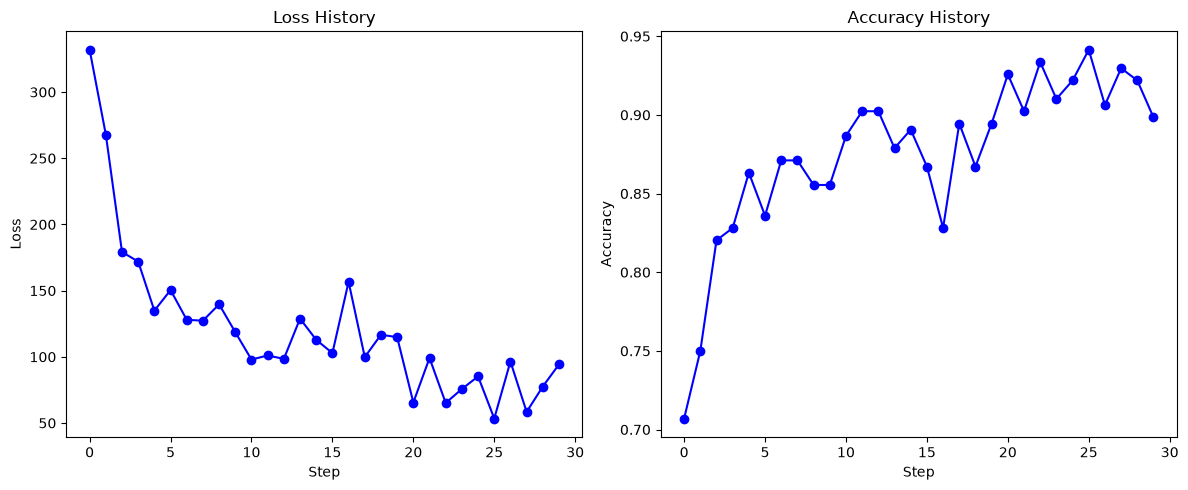

In [113]:
# Виведіть графіки залежності зміни точності і втрат від кроку
# Якщо все зроблено правильно, то точність повинна зростати, а втрати зменшуватись

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.flatten()

axes[0].plot(range(0, len(loss_history)), loss_history, marker='o', color='b', linestyle='-')
axes[0].set_title('Loss History')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')

axes[1].plot(range(0, len(accuracy_history)), accuracy_history, marker='o', color='b', linestyle='-')
axes[1].set_title('Accuracy History')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Accuracy')

plt.tight_layout()
plt.show()


In [114]:
prediction = neural_net(x_test)
prediction = tf.argmax(prediction, 1)
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       980
           1       0.97      0.97      0.97      1135
           2       0.92      0.88      0.90      1032
           3       0.89      0.88      0.89      1010
           4       0.93      0.87      0.90       982
           5       0.87      0.85      0.86       892
           6       0.92      0.92      0.92       958
           7       0.88      0.92      0.90      1028
           8       0.85      0.87      0.86       974
           9       0.85      0.89      0.87      1009

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



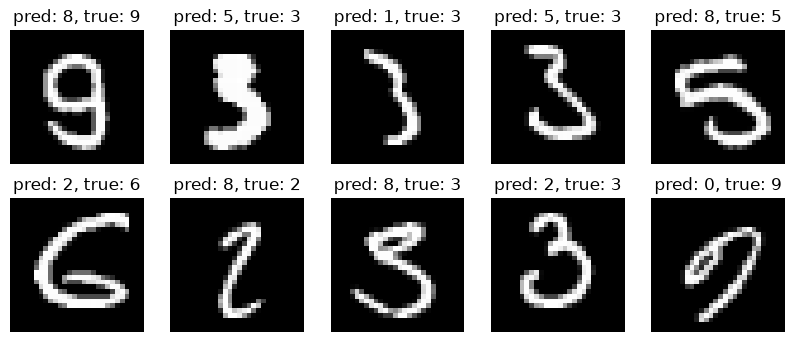

In [115]:
# Протестуйте навчену нейромережу на 10 зображеннях. З тестової вибірки візьміть 5
# випадкових зображень і передайте їх у нейронну мережу.
# Виведіть зображення та випишіть  поруч відповідь нейромережі.
# Зробіть висновок про те, чи помиляється твоя нейронна мережа, і якщо так, то як часто?

n_tests = 100
n_show = 10

sub_dataset = test_data.take(n_tests)

wrong_samples = []

for x, y in sub_dataset:
    x_batch = tf.expand_dims(x, axis=0)
    pred = tf.argmax(neural_net(x_batch), axis=1).numpy()[0]
    true = y.numpy()

    if pred != true:
        wrong_samples.append((x, pred, true))
        if len(wrong_samples) >= n_show:
            break

figure = plt.figure(figsize=(10, 4))
cols, rows = 5, 2
sub_dataset = test_data.take(10)

for index, (x, pred, true) in enumerate(wrong_samples, 1):
    figure.add_subplot(rows, cols, index)
    plt.axis("off")
    plt.title(f"pred: {pred}, true: {true}")

    img = tf.reshape(x, (28, 28)).numpy()
    plt.imshow(img, cmap="gray")

plt.show()

Опираючись на classification_report, можемо сказати висновок, що створена модель помиляється у приблизно 10% випадків. <br/>
На наведеному графіку показані випадки, коли мережа помилково класифікувала зображення.

## Pytorch імплементація

In [42]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

In [75]:
class NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.Sigmoid(),
            nn.Linear(512, 512),
            nn.Sigmoid(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [76]:
loss_history = []
accuracy_history = []


model = NN().to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

loss_fn = nn.CrossEntropyLoss()
def accuracy_fn(model, x, y):
    model.eval()
    with torch.no_grad():
        y_pred = model(x)
        predicted = torch.argmax(y_pred, dim=1)
        acc = (predicted == y).float().mean().item()
    return acc


for step, (batch_x, batch_y) in enumerate(train_data.take(training_steps), 1):
    model.train()

    x_t = torch.tensor(batch_x, dtype=torch.float32).to(device)
    y_t = torch.tensor(batch_y, dtype=torch.long).to(device)

    y_pred = model(x_t)

    loss = loss_fn(y_pred, y_t)
    loss.backward()

    optimizer.step()
    optimizer.zero_grad()

    if step % display_step == 0:
        loss_history.append(loss.item())
        accuracy_history.append(accuracy_fn(model, x_t, y_t))

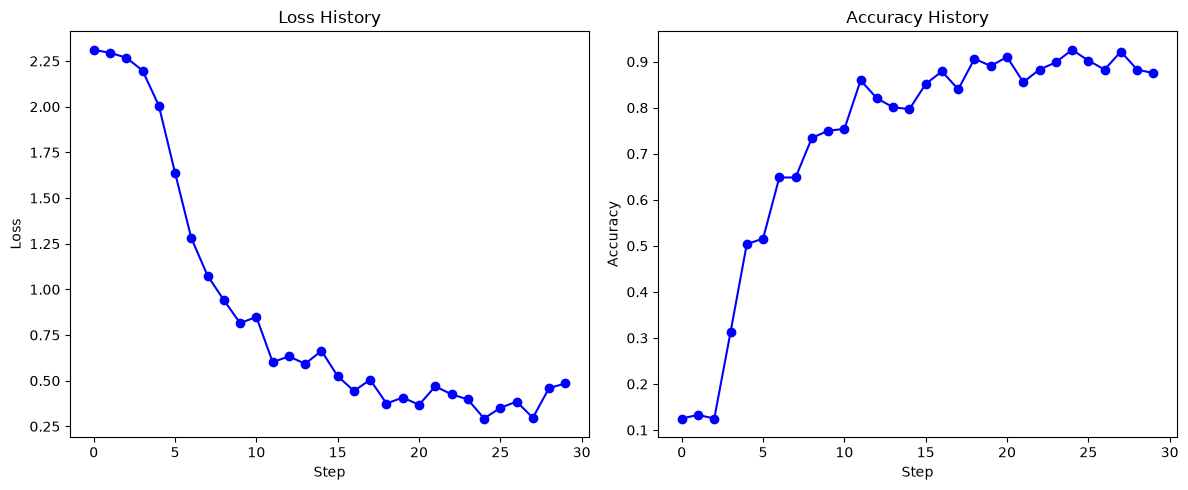

In [77]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.flatten()

axes[0].plot(range(0, len(loss_history)), loss_history, marker='o', color='b', linestyle='-')
axes[0].set_title('Loss History')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')

axes[1].plot(range(0, len(accuracy_history)), accuracy_history, marker='o', color='b', linestyle='-')
axes[1].set_title('Accuracy History')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Accuracy')

plt.tight_layout()
plt.show()


In [78]:
x_t = torch.tensor(x_test, dtype=torch.float32).to(device)
y_t = torch.tensor(y_test, dtype=torch.long).to(device)

prediction = model(x_t)
prediction = torch.argmax(prediction, 1)
print(classification_report(y_t.cpu().numpy(), prediction.cpu().numpy()))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95       980
           1       0.96      0.97      0.96      1135
           2       0.88      0.89      0.88      1032
           3       0.90      0.88      0.89      1010
           4       0.90      0.90      0.90       982
           5       0.84      0.82      0.83       892
           6       0.90      0.92      0.91       958
           7       0.93      0.90      0.91      1028
           8       0.86      0.83      0.85       974
           9       0.87      0.87      0.87      1009

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000

